# LSMC Duration Sweep

Diagnostic notebook: execute `04_lsmc_valuation.ipynb` for durations from `0.5h` to `4.0h` in `0.5h` steps, then plot the LSMC annual mean. This temporarily widens `src.config.VALID_ASSET_DURATIONS_H` inside each executed notebook so the production config file is not edited.

In [1]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
import sys
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
SOURCE_NOTEBOOK = NOTEBOOK_DIR / "04_lsmc_valuation.ipynb"

SWEEP_DURATIONS_H = [x / 2 for x in range(1, 9)]  # 0.5, 1.0, ..., 4.0
SWEEP_ALLOWED_DURATIONS = tuple(SWEEP_DURATIONS_H)
PHASE4_RUN_MODE_FOR_SWEEP = "medium"  # use "partial" only for a quick smoke test
SWEEP_SCENARIOS = {
    "energy_only": {"dc_levels": [0.0], "qr_levels": [0.0]},
    "cooptimised": {},
}
SKIP_COMPLETED_EXECUTIONS = False  # keep False when changing run mode or code
OUTPUT_DIR = PROCESSED / "notebook_runs" / f"lsmc_duration_sweep_{datetime.now():%Y%m%d_%H%M%S}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Sweep output dir: {OUTPUT_DIR}")
print(f"Durations: {SWEEP_DURATIONS_H}")
print(f"Scenarios: {list(SWEEP_SCENARIOS)}")
print(f"Phase 4 run mode: {PHASE4_RUN_MODE_FOR_SWEEP}")
print(f"Skip completed executions: {SKIP_COMPLETED_EXECUTIONS}")

Project root: g:\My Drive\Research\bess_project
Sweep output dir: g:\My Drive\Research\bess_project\data\processed\notebook_runs\lsmc_duration_sweep_20260501_101348
Durations: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
Phase 4 run mode: medium
Skip completed executions: False


In [2]:
def duration_label(duration_h: float) -> str:
    return f"{duration_h:g}h"


def backup_existing_outputs(duration_h: float) -> None:
    """Keep a copy of existing duration-labelled Phase 4 outputs before the sweep overwrites them."""
    label = duration_label(duration_h)
    backup_dir = OUTPUT_DIR / "pre_sweep_backups"
    backup_dir.mkdir(exist_ok=True)
    for suffix in ("json", "png", "pkl"):
        for path in PROCESSED.glob(f"lsmc_valuation*_{label}.{suffix}"):
            shutil.copy2(path, backup_dir / path.name)


def parameterized_notebook(src_path: Path, duration_h: float, scenario_name: str, overrides: dict, work_dir: Path) -> Path:
    """Create a temporary notebook with duration and config overrides injected as the first cell."""
    nb = json.loads(src_path.read_text(encoding="utf-8"))
    label = duration_label(duration_h)
    scenario_dir = work_dir / scenario_name
    scenario_dir.mkdir(exist_ok=True)
    param_cell = {
        "cell_type": "code",
        "execution_count": None,
        "metadata": {"tags": ["parameters"]},
        "outputs": [],
        "source": [
            "import src.config as _sweep_config\n",
            f"_sweep_config.VALID_ASSET_DURATIONS_H = {SWEEP_ALLOWED_DURATIONS!r}\n",
            f"VALUATION_DURATION_H = {duration_h!r}\n",
            f"PHASE4_RUN_MODE = {PHASE4_RUN_MODE_FOR_SWEEP!r}\n",
            f"PHASE4_MODE_OVERRIDES = {overrides!r}\n",
            f"print('Injected LSMC duration sweep: {label}')\n",
            f"print('Injected sweep scenario: {scenario_name}')\n",
            f"print('Injected Phase 4 run mode: {PHASE4_RUN_MODE_FOR_SWEEP}')\n",
            "print('Injected Phase 4 overrides:', PHASE4_MODE_OVERRIDES)\n",
        ],
    }
    nb["cells"] = [param_cell, *nb.get("cells", [])]
    tmp_path = scenario_dir / f"{src_path.stem}_{scenario_name}_{label}.parameterized.ipynb"
    tmp_path.write_text(json.dumps(nb, indent=1), encoding="utf-8")
    return tmp_path

In [3]:
if "duration_label" not in globals():
    def duration_label(duration_h: float) -> str:
        return f"{duration_h:g}h"

if "backup_existing_outputs" not in globals():
    def backup_existing_outputs(duration_h: float) -> None:
        label = duration_label(duration_h)
        backup_dir = OUTPUT_DIR / "pre_sweep_backups"
        backup_dir.mkdir(exist_ok=True)
        for suffix in ("json", "png", "pkl"):
            for path in PROCESSED.glob(f"lsmc_valuation*_{label}.{suffix}"):
                shutil.copy2(path, backup_dir / path.name)

env = os.environ.copy()
env["PYTHONPATH"] = str(PROJECT_ROOT) + os.pathsep + env.get("PYTHONPATH", "")

run_rows = []

for scenario_name, overrides in SWEEP_SCENARIOS.items():
    scenario_dir = OUTPUT_DIR / scenario_name
    scenario_dir.mkdir(exist_ok=True)

    for duration_h in SWEEP_DURATIONS_H:
        label = duration_label(duration_h)
        backup_existing_outputs(duration_h)
        tmp_src = parameterized_notebook(SOURCE_NOTEBOOK, duration_h, scenario_name, overrides, OUTPUT_DIR)
        out_name = f"{SOURCE_NOTEBOOK.stem}_{scenario_name}_{label}.executed.ipynb"
        out_path = scenario_dir / out_name
        summary_copy = scenario_dir / f"lsmc_valuation_summary_{scenario_name}_{label}.json"
        if SKIP_COMPLETED_EXECUTIONS and out_path.exists() and summary_copy.exists():
            print(f"Skipping {scenario_name} {label}; executed notebook already exists: {out_path.name}")
            run_rows.append({
                "scenario": scenario_name,
                "duration_h": duration_h,
                "duration_label": label,
                "returncode": 0,
                "elapsed_s": 0.0,
                "executed_notebook": out_name,
                "summary_json": summary_copy.name,
                "skipped": True,
            })
            continue
        cmd = [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        "--to",
        "notebook",
        "--execute",
        "--ExecutePreprocessor.timeout=-1",
        "--ExecutePreprocessor.kernel_name=python3",
        f"--output-dir={scenario_dir}",
        f"--output={out_name}",
        str(tmp_src),
        ]

        print("\n" + "=" * 80)
        print(f"Executing {SOURCE_NOTEBOOK.name} for {scenario_name} / {label}")
        print("=" * 80)
        started = time.time()
        proc = subprocess.run(
            cmd,
            cwd=PROJECT_ROOT,
            env=env,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
        )
        elapsed = time.time() - started
        print(proc.stdout[-4000:])
        print(f"Finished {scenario_name} / {label} in {elapsed:.1f}s with return code {proc.returncode}")
        if proc.returncode == 0:
            produced_summary = PROCESSED / f"lsmc_valuation_summary_{label}.json"
            if produced_summary.exists():
                shutil.copy2(produced_summary, summary_copy)
            produced_plot = PROCESSED / f"lsmc_valuation_{label}.png"
            if produced_plot.exists():
                shutil.copy2(produced_plot, scenario_dir / f"lsmc_valuation_{scenario_name}_{label}.png")

        run_rows.append({
            "scenario": scenario_name,
            "duration_h": duration_h,
            "duration_label": label,
            "returncode": proc.returncode,
            "elapsed_s": elapsed,
            "executed_notebook": out_name,
            "summary_json": summary_copy.name,
            "skipped": False,
        })
        if proc.returncode != 0:
            raise RuntimeError(f"04_lsmc_valuation.ipynb failed for {scenario_name} / {label}")

run_summary = pd.DataFrame(run_rows)
run_summary.to_csv(OUTPUT_DIR / "lsmc_duration_sweep_run_summary.csv", index=False)
run_summary


Executing 04_lsmc_valuation.ipynb for 0.5h
[NbConvertApp] Converting notebook g:\My Drive\Research\bess_project\data\processed\notebook_runs\lsmc_duration_sweep_20260501_101348\04_lsmc_valuation_0.5h.parameterized.ipynb to notebook
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\zmq\_future.py:718: RuntimeWarning: Proactor event loop does not implement add_reader family of methods required for zmq. Registering an additional selector thread for add_reader support via tornado. Use `asyncio.set_event_loop_policy(WindowsSelectorEventLoopPol

,duration_h,duration_label,returncode,elapsed_s,executed_notebook,skipped
0,0.5,0.5h,0,136.779484,04_lsmc_valuation_0.5h.executed.ipynb,False
1,1.0,1h,0,148.200346,04_lsmc_valuation_1h.executed.ipynb,False
2,1.5,1.5h,0,243.368088,04_lsmc_valuation_1.5h.executed.ipynb,False
3,2.0,2h,0,305.628928,04_lsmc_valuation_2h.executed.ipynb,False
4,2.5,2.5h,0,321.957401,04_lsmc_valuation_2.5h.executed.ipynb,False
5,3.0,3h,0,219.765634,04_lsmc_valuation_3h.executed.ipynb,False
6,3.5,3.5h,0,181.003980,04_lsmc_valuation_3.5h.executed.ipynb,False
7,4.0,4h,0,183.325545,04_lsmc_valuation_4h.executed.ipynb,False


In [4]:
if "duration_label" not in globals():
    def duration_label(duration_h: float) -> str:
        return f"{duration_h:g}h"

summary_rows = []
expected_run_mode = PHASE4_RUN_MODE_FOR_SWEEP

for scenario_name in SWEEP_SCENARIOS:
    scenario_dir = OUTPUT_DIR / scenario_name
    for duration_h in SWEEP_DURATIONS_H:
        label = duration_label(duration_h)
        path = scenario_dir / f"lsmc_valuation_summary_{scenario_name}_{label}.json"
        if not path.exists():
            raise FileNotFoundError(path)
        with path.open("r", encoding="utf-8") as f:
            summary = json.load(f)
        actual_run_mode = summary.get("run_mode")
        if actual_run_mode != expected_run_mode:
            raise RuntimeError(
                f"{path.name} has run_mode={actual_run_mode!r}, expected {expected_run_mode!r}. "
                "Rerun the execution cell with SKIP_COMPLETED_EXECUTIONS = False."
            )
        action = summary.get("action_distribution", {})
        diag = summary.get("lsmc_diagnostics", {})
        by_mode = action.get("by_mode", [])
        true_idle_fraction = sum(
            mode.get("fraction", 0.0)
            for mode in by_mode
            if mode.get("net_frac") == 0.0 and mode.get("r_dc_frac") == 0.0 and mode.get("r_qr_frac") == 0.0
        )
        reserve_only_fraction = sum(
            mode.get("fraction", 0.0)
            for mode in by_mode
            if mode.get("net_frac") == 0.0 and (mode.get("r_dc_frac", 0.0) > 0.0 or mode.get("r_qr_frac", 0.0) > 0.0)
        )
        summary_rows.append({
            "scenario": scenario_name,
            "duration_h": duration_h,
            "duration_label": label,
            "asset_mwh": summary.get("asset_mwh"),
            "run_mode": summary.get("run_mode"),
            "n_paths": summary.get("n_paths"),
            "n_steps": summary.get("n_steps"),
            "valuation_horizon_years": summary.get("valuation_horizon_years"),
            "annualization_factor": summary.get("annualization_factor"),
            "lsmc_annual_mean_gbp": summary.get("mtm_gbp_annualized", {}).get("mean"),
            "lsmc_gbp_per_mw_year": summary.get("mtm_gbp_per_mw_year", {}).get("mean"),
            "cashflow_mean_gbp": action.get("cashflow_mean_gbp"),
            "charge_fraction": action.get("charge_fraction"),
            "discharge_fraction": action.get("discharge_fraction"),
            "idle_fraction": action.get("idle_fraction"),
            "true_idle_fraction": true_idle_fraction,
            "reserve_only_fraction": reserve_only_fraction,
            "dominant_action_fraction": action.get("dominant_action_fraction"),
            "beta_abs_max": diag.get("beta_abs_max"),
            "target_std_max": diag.get("target_std_max"),
            "continuation_clip_fraction_max": diag.get("continuation_clip_fraction_max"),
        })

sweep = pd.DataFrame(summary_rows)
sweep.to_csv(PROCESSED / "lsmc_duration_sweep.csv", index=False)
sweep.to_csv(OUTPUT_DIR / "lsmc_duration_sweep.csv", index=False)
sweep

,duration_h,duration_label,asset_mwh,run_mode,n_paths,n_steps,valuation_horizon_years,annualization_factor,lsmc_annual_mean_gbp,lsmc_gbp_per_mw_year,cashflow_mean_gbp,charge_fraction,discharge_fraction,idle_fraction,true_idle_fraction,reserve_only_fraction,dominant_action_fraction,beta_abs_max,target_std_max,continuation_clip_fraction_max
0,0.5,0.5h,50.0,medium,1000,4320,0.246575,4.055556,864246,8642,49.878902,0.000000,0.000000,1.000000,0.022519,0.977481,0.977481,6.753486e+05,9495.745912,0.0
1,1.0,1h,100.0,medium,1000,4320,0.246575,4.055556,6070324,60703,350.423462,0.068978,0.060889,0.870132,0.126990,0.743142,0.483678,9.884630e+06,92054.388556,0.0
2,1.5,1.5h,150.0,medium,1000,4320,0.246575,4.055556,2424745,24247,139.722961,0.022741,0.020131,0.957128,0.518062,0.439066,0.518062,6.942101e+06,97668.901649,0.0
3,2.0,2h,200.0,medium,1000,4320,0.246575,4.055556,4492959,44930,259.421204,0.034244,0.030394,0.935362,0.027445,0.907917,0.599960,5.293887e+06,100860.117078,0.0
4,2.5,2.5h,250.0,medium,1000,4320,0.246575,4.055556,2172098,21721,125.377808,0.006862,0.006347,0.986790,0.055035,0.931755,0.581253,5.305463e+06,102390.201183,0.0
5,3.0,3h,300.0,medium,1000,4320,0.246575,4.055556,884473,8845,50.667725,0.004969,0.005261,0.989771,0.776566,0.213205,0.776566,5.507779e+06,107293.733412,0.0
6,3.5,3.5h,350.0,medium,1000,4320,0.246575,4.055556,1451550,14515,83.431656,0.003498,0.004061,0.992441,0.546071,0.446370,0.546071,5.586645e+06,109144.343105,0.0
7,4.0,4h,400.0,medium,1000,4320,0.246575,4.055556,1989898,19899,114.581474,0.002853,0.003422,0.993726,0.457215,0.536510,0.520212,5.691486e+06,110757.257845,0.0


Saved plot: g:\My Drive\Research\bess_project\data\processed\lsmc_duration_sweep.png


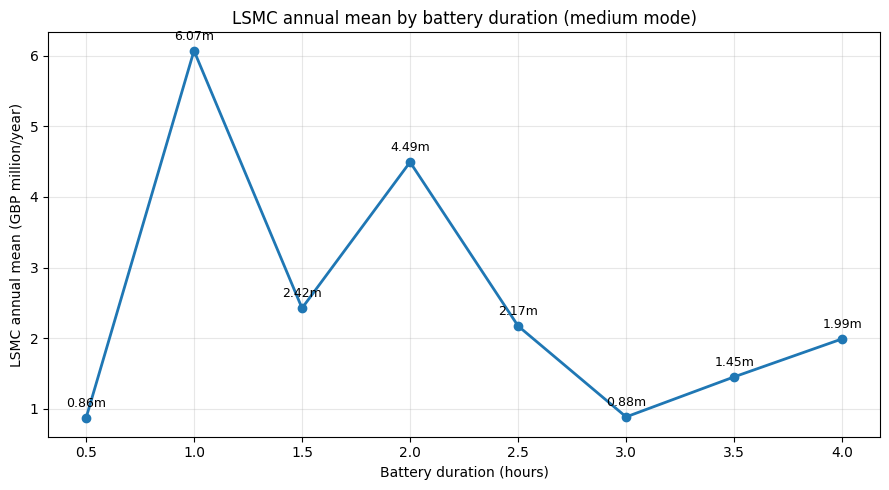

Saved diagnostic plot: g:\My Drive\Research\bess_project\data\processed\lsmc_duration_sweep_diagnostics.png


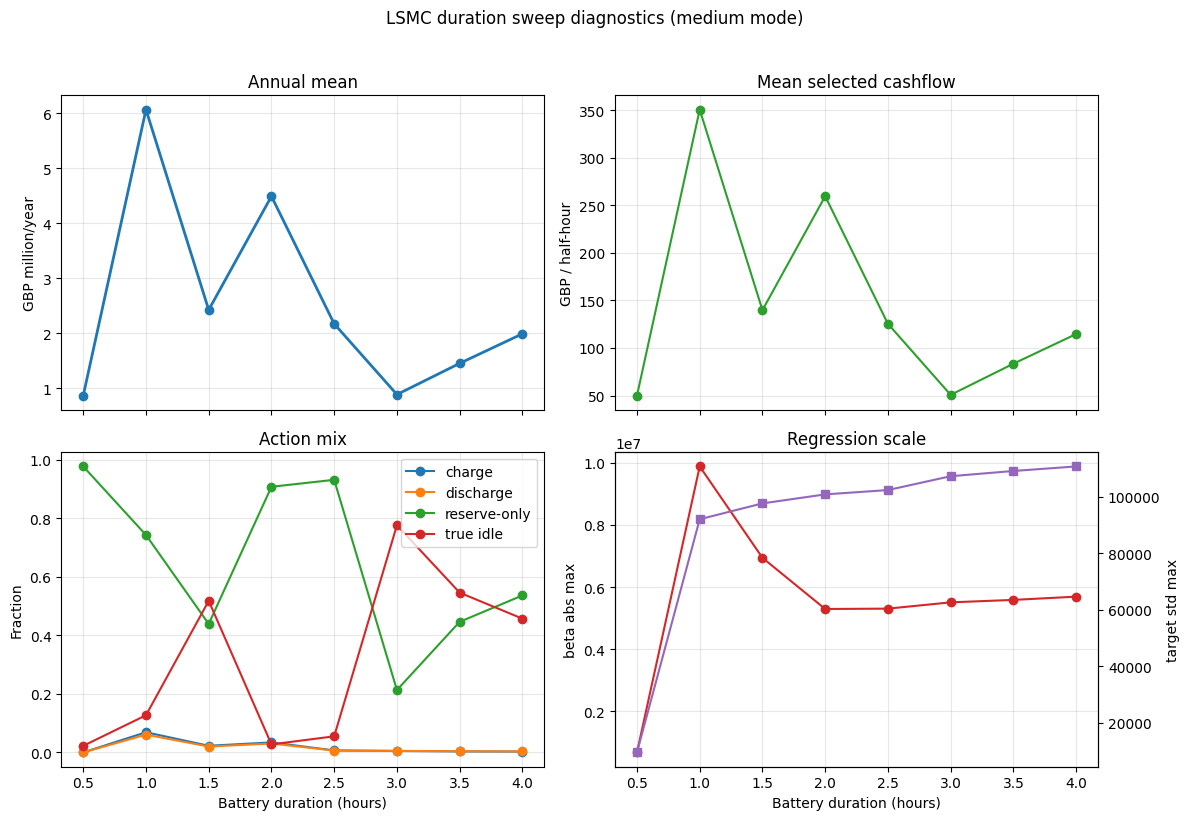

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for scenario_name, group in sweep.groupby("scenario", sort=False):
    group = group.sort_values("duration_h")
    annual_mean_m = group["lsmc_annual_mean_gbp"] / 1_000_000
    ax.plot(group["duration_h"], annual_mean_m, marker="o", linewidth=2, label=scenario_name)
ax.set_title(f"LSMC annual mean by battery duration ({PHASE4_RUN_MODE_FOR_SWEEP} mode)")
ax.set_xlabel("Battery duration (hours)")
ax.set_ylabel("LSMC annual mean (GBP million/year)")
ax.set_xticks(SWEEP_DURATIONS_H)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

plot_path = PROCESSED / "lsmc_duration_sweep.png"
fig.savefig(plot_path, dpi=160)
fig.savefig(OUTPUT_DIR / "lsmc_duration_sweep.png", dpi=160)
print(f"Saved plot: {plot_path}")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax0, ax1, ax2, ax3 = axes.ravel()

for scenario_name, group in sweep.groupby("scenario", sort=False):
    group = group.sort_values("duration_h")
    ax0.plot(group["duration_h"], group["lsmc_annual_mean_gbp"] / 1_000_000, marker="o", linewidth=2, label=scenario_name)
ax0.set_title("Annual mean")
ax0.set_ylabel("GBP million/year")
ax0.legend()
ax0.grid(True, alpha=0.3)

for scenario_name, group in sweep.groupby("scenario", sort=False):
    group = group.sort_values("duration_h")
    ax1.plot(group["duration_h"], group["cashflow_mean_gbp"], marker="o", label=scenario_name)
ax1.set_title("Mean selected cashflow")
ax1.set_ylabel("GBP / half-hour")
ax1.legend()
ax1.grid(True, alpha=0.3)

for scenario_name, group in sweep.groupby("scenario", sort=False):
    group = group.sort_values("duration_h")
    ax2.plot(group["duration_h"], group["reserve_only_fraction"], marker="o", label=f"{scenario_name} reserve-only")
    ax2.plot(group["duration_h"], group["true_idle_fraction"], marker="s", linestyle="--", label=f"{scenario_name} true idle")
ax2.set_title("Idle / reserve-only mix")
ax2.set_ylabel("Fraction")
ax2.legend()
ax2.grid(True, alpha=0.3)

for scenario_name, group in sweep.groupby("scenario", sort=False):
    group = group.sort_values("duration_h")
    ax3.plot(group["duration_h"], group["beta_abs_max"], marker="o", label=scenario_name)
ax3.set_title("Regression scale")
ax3.set_ylabel("beta abs max")
ax3.legend()
ax3.grid(True, alpha=0.3)

for axis in axes[-1, :]:
    axis.set_xlabel("Battery duration (hours)")
    axis.set_xticks(SWEEP_DURATIONS_H)

fig.suptitle(f"LSMC duration sweep diagnostics ({PHASE4_RUN_MODE_FOR_SWEEP} mode)", y=1.02)
fig.tight_layout()
diag_plot_path = PROCESSED / "lsmc_duration_sweep_diagnostics.png"
fig.savefig(diag_plot_path, dpi=160, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "lsmc_duration_sweep_diagnostics.png", dpi=160, bbox_inches="tight")
print(f"Saved diagnostic plot: {diag_plot_path}")
plt.show()

## Optional Restore

The sweep runs Phase 4 directly, so it overwrites local `lsmc_valuation_*_<duration>` files in `data/processed`. Run the next cell if you want to restore any files that existed before the sweep.

In [6]:
backup_dir = OUTPUT_DIR / "pre_sweep_backups"
if backup_dir.exists():
    restored = []
    for path in backup_dir.glob("lsmc_valuation*"):
        target = PROCESSED / path.name
        shutil.copy2(path, target)
        restored.append(target.name)
    print(f"Restored {len(restored)} files from {backup_dir}")
    restored
else:
    print("No pre-sweep backup directory found for this run.")

Restored 24 files from g:\My Drive\Research\bess_project\data\processed\notebook_runs\lsmc_duration_sweep_20260501_101348\pre_sweep_backups
